In [85]:
%pip install langgraph
%pip install langsmith
%pip install IPython
%pip install langchain_tavily
%pip install langchain-google-genai
%pip install google-genai
%pip install google-generativeai

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


...


[notice] A new release of pip is available: 26.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [86]:
from typing import Annotated 
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END 
from langgraph.graph.message import add_messages
from langgraph.prebuilt import ToolNode, tools_condition


import os
import dotenv
from dotenv import load_dotenv
from langchain.chat_models import init_chat_model
from dotenv import load_dotenv
from langchain_google_genai import ChatGoogleGenerativeAI

load_dotenv()


model = ChatGoogleGenerativeAI(model='gemini-3.5-flash')
response = model.invoke("What is the capital of France?")
print(response.content)

model.invoke("What is the weather today bro?")


Both GOOGLE_API_KEY and GEMINI_API_KEY are set. Using GOOGLE_API_KEY.


[{'type': 'text', 'text': 'The capital of France is **Paris**.', 'extras': {'signature': 'EpEDCo4DAQw51scXxjrSXzShilcMzc0hERPyupL7gWawCj6fzXujjEghh4PAKishyKhueaDZWx39x+2sXuMalJOckNYt4K+MCfw7hOyZL1dvFB8kfIUwcq4Du0RgtzvvDHOw1QeWvUycdVcWQR3yrY3kHKybpQgtM1deV+u9LZhISs4ZBpBAuNSmQk6e1RK9ml/HQYcRNYM1n2Qnmo1l5xnRzC6AN0BW2mhxvwihp+SvCqoWfG6AWDqoAS7E7Yem3dXR+k140gndwHDJ/7atMkg9T77PmIgvGZD07DCxg/sXxZtpM53nIu7mNI0WPVWnMInWJpQhHQaElZo5hIc+94SuCYNqGvgGzVnvLbBREVEmdahvthywHkDZaJeio52DK7XoXJes2yfmk9LKhPnHOBg3t6VrjTkeADuqtmRVdacbOavT4mt/BNGtF9uIIQs7Gt5/JJHv0vHBv50hgitw0EYWgNrcXznNP3jF1qZWTkbCkIzBvV8aEPyq1ToEIFGZVzWTHqoP0tFpCIr/ircFadBT0vQ='}}]


AIMessage(content=[{'type': 'text', 'text': "I'd love to help you out, bro, but I don't have real-time access to live weather data, and I don't know where you're located! \n\nYour best bet is to check the weather app on your phone or do a quick Google search for your city. Hope it's nice and sunny wherever you are!", 'extras': {'signature': 'EsoJCscJAQw51sckx3/9EdWgeTEK9iEErtENPeC/H0eAEcmtfqcoXiZZSh06Ih4H39iJumU55j5jyh0rdUjToxKzTL4B6ILzoosqp57Xce/4EN3pZ1EIE0mjroF2ctZfDE/w2qfcoUWD+dMnBZ/uzBGFviMgMbHdR5QK6xsoUHxmmMsjCQX/ZFBq+ssIx104xkYsvYJp5Q6yCu6TTnFVWsdV8Ps0CY9puh4gkAeTxl7gOljdvXK5wfmWchvSVVOk68bzKy1fjkUwN9kF3yC73Bxmx/joa1/diic9smecGy9Mrh5wEvoM41N39LkgQ+cSmx9zMcCrDtHn6rQjKVogmrLrCIHIXT6TRycBYxOz/z7BwU9Rm4k3kPLRoVo4ntk9HOySmf0gpT9uFPBn9ZerF4PqbhD0LxPDiUFAEZr4RSd8i73LeXz4oSlbMr5s1zejki/WVk4cwQr6i6huOXGuPOmbXb5way5Nv3ZO3QpXJfucNF9nPGqE3GknS/tYHylESroDeBHFgESUaOsBvZ+cLj0u/VERYd/QjacEkMmGrk/GxxrtbGcYtS2wEisL/6uzGVOoJBoHo4g9HTXVRUcfr3gR7XFcZP+vhf9ASgA1RjTaVepBnqD9TSeaL+Caou2/b5O8IZmRk9FhLnvV

In [87]:
class State(TypedDict):
    """State of the chatbot conversation. Messages are not replaced but added in the list of the messages."""
    messages: Annotated[list[str], add_messages] #in LangGraph is used to attach reducer functions to state fields. The reducer tells LangGraph how to merge updates from multiple nodes or graph branches.



In [88]:
from langchain_tavily import TavilySearch

tool = TavilySearch(max_results=2)

tool.invoke("What is the capital of France?")

{'query': 'What is the capital of France?',
 'follow_up_questions': None,
 'answer': None,
 'images': [],
 'results': [{'url': 'https://www.facebook.com/groups/302915185514582/posts/740821111723985',
   'title': 'What is the capital of France? - Facebook',
   'content': 'Paris is the capital and largest city of France, renowned globally for its cultural, historical, and artistic significance. Often called the "',
   'score': 0.8969848,
   'raw_content': None},
  {'url': 'https://en.wikipedia.org/wiki/Paris',
   'title': 'Paris - Wikipedia',
   'content': "As the capital of France, Paris is the seat of France's national government ; Both houses of the French Parliament ; France's highest courts are located in Paris.",
   'score': 0.8939131,
   'raw_content': None}],
 'response_time': 0.0,
 'request_id': 'eb07b774-9b64-4e1c-b8ad-81b2d7a34ec5'}

In [89]:

def multiply(a: int , b: int ) -> int:
    """Multiplies two numbers.
    
    Args:
        a: The first number.
        b: The second number.
    Returns:
        The product of a and b."""
    
    return a*b

In [90]:
tools = [tool, multiply]

In [91]:
llm_with_tools = model.bind_tools(tools)

Key 'additionalProperties' is not supported in schema, ignoring


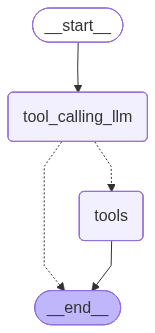

In [92]:
from IPython.display import Image, display

def tool_calling_llm(state: State):
    return {"messages": [llm_with_tools.invoke(state["messages"])]}


def tool_calling_llm(state: State):
    return {"messages": [llm_with_tools.invoke(state["messages"])]}

builder = StateGraph(State)
builder.add_node("tool_calling_llm", tool_calling_llm)
builder.add_node("tools", ToolNode(tools))

builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    
    tools_condition,

)
builder.add_edge("tools", END)

graph = builder.compile()

display(Image(graph.get_graph().draw_mermaid_png()))


In [93]:
response = graph.invoke({"messages": "What is the recent AI news and please multiply 5 and 3?"})

for m in response['messages']:
    m.pretty_print()




Key 'additional_properties' is not supported in schema, ignoring
Key 'defs' is not supported in schema, ignoring
Key 'ref' is not supported in schema, ignoring
Key 'any_of' is not supported in schema, ignoring
Key 'example' is not supported in schema, ignoring
Key 'max_items' is not supported in schema, ignoring
Key 'max_length' is not supported in schema, ignoring
Key 'max_properties' is not supported in schema, ignoring
Key 'min_items' is not supported in schema, ignoring
Key 'min_length' is not supported in schema, ignoring
Key 'min_properties' is not supported in schema, ignoring
Key 'property_ordering' is not supported in schema, ignoring
Key 'additional_properties' is not supported in schema, ignoring
Key 'defs' is not supported in schema, ignoring
Key 'ref' is not supported in schema, ignoring
Key 'any_of' is not supported in schema, ignoring
Key 'example' is not supported in schema, ignoring
Key 'max_items' is not supported in schema, ignoring
Key 'max_length' is not supported 

================================ Human Message =================================

What is the recent AI news and please multiply 5 and 3?
================================== Ai Message ==================================

[]
Tool Calls:
  tavily_search (iklj76ih)
 Call ID: iklj76ih
  Args:
    query: recent AI news
    topic: news
  multiply (lkgr0e8t)
 Call ID: lkgr0e8t
  Args:
    a: 5
    b: 3
================================= Tool Message =================================
Name: tavily_search

{"query": "recent AI news", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.axios.com/2026/06/08/ai-news-nvidia-cosmos-3-openai-sites-solara-rtx-spark", "title": "Axios C-Suite: 3 new AI developments for the week of June 6 - Axios", "score": 0.7783298, "published_date": "Mon, 08 Jun 2026 09:57:05 GMT", "content": "# Axios C-Suite: 3 new AI developments for the week of June 6. Fast action AI software:** OpenAI launched Sites, a Codex feature that lets y

# ReAct Agents

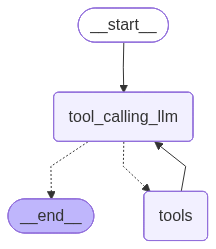

In [94]:
from IPython.display import Image, display

def tool_calling_llm(state: State):
    return {"messages": [llm_with_tools.invoke(state["messages"])]}


def tool_calling_llm(state: State):
    return {"messages": [llm_with_tools.invoke(state["messages"])]}

builder = StateGraph(State)
builder.add_node("tool_calling_llm", tool_calling_llm)
builder.add_node("tools", ToolNode(tools))

builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    
    tools_condition,

)
builder.add_edge("tools", "tool_calling_llm")
builder.add_edge("tool_calling_llm", END)

graph = builder.compile()

display(Image(graph.get_graph().draw_mermaid_png()))


In [95]:
response = graph.invoke({"messages": "What is the recent AI news and please multiply 5 and 3?"})

for m in response['messages']:
    m.pretty_print()

Key 'additional_properties' is not supported in schema, ignoring
Key 'defs' is not supported in schema, ignoring
Key 'ref' is not supported in schema, ignoring
Key 'any_of' is not supported in schema, ignoring
Key 'example' is not supported in schema, ignoring
Key 'max_items' is not supported in schema, ignoring
Key 'max_length' is not supported in schema, ignoring
Key 'max_properties' is not supported in schema, ignoring
Key 'min_items' is not supported in schema, ignoring
Key 'min_length' is not supported in schema, ignoring
Key 'min_properties' is not supported in schema, ignoring
Key 'property_ordering' is not supported in schema, ignoring
Key 'additional_properties' is not supported in schema, ignoring
Key 'defs' is not supported in schema, ignoring
Key 'ref' is not supported in schema, ignoring
Key 'any_of' is not supported in schema, ignoring
Key 'example' is not supported in schema, ignoring
Key 'max_items' is not supported in schema, ignoring
Key 'max_length' is not supported 

================================ Human Message =================================

What is the recent AI news and please multiply 5 and 3?
================================== Ai Message ==================================

[]
Tool Calls:
  tavily_search (q2kkwio7)
 Call ID: q2kkwio7
  Args:
    topic: news
    query: recent AI news
  multiply (0e1hfgyh)
 Call ID: 0e1hfgyh
  Args:
    b: 3
    a: 5
================================= Tool Message =================================
Name: tavily_search

{"query": "recent AI news", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.axios.com/2026/06/08/ai-news-nvidia-cosmos-3-openai-sites-solara-rtx-spark", "title": "Axios C-Suite: 3 new AI developments for the week of June 6 - Axios", "score": 0.7783298, "published_date": "Mon, 08 Jun 2026 09:57:05 GMT", "content": "# Axios C-Suite: 3 new AI developments for the week of June 6. Fast action AI software:** OpenAI launched Sites, a Codex feature that lets y

# Memory Saver - Checkpoints

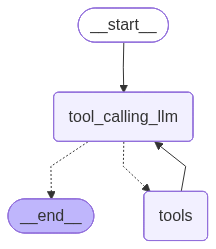

In [96]:
from IPython.display import Image, display
from langgraph.checkpoint.memory import MemorySaver

memory = MemorySaver()

def tool_calling_llm(state: State):
    return {"messages": [llm_with_tools.invoke(state["messages"])]}


def tool_calling_llm(state: State):
    return {"messages": [llm_with_tools.invoke(state["messages"])]}

builder = StateGraph(State)
builder.add_node("tool_calling_llm", tool_calling_llm)
builder.add_node("tools", ToolNode(tools))

builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    
    tools_condition,

)
builder.add_edge("tools", "tool_calling_llm")
builder.add_edge("tool_calling_llm", END)

piper = builder.compile(checkpointer = memory)

display(Image(piper.get_graph().draw_mermaid_png()))


In [97]:
config = {"configurable": {"thread_id": "1"}}

piper.invoke({"messages": "Hi My name is Siddhanth."}, config = config)

Key 'additional_properties' is not supported in schema, ignoring
Key 'defs' is not supported in schema, ignoring
Key 'ref' is not supported in schema, ignoring
Key 'any_of' is not supported in schema, ignoring
Key 'example' is not supported in schema, ignoring
Key 'max_items' is not supported in schema, ignoring
Key 'max_length' is not supported in schema, ignoring
Key 'max_properties' is not supported in schema, ignoring
Key 'min_items' is not supported in schema, ignoring
Key 'min_length' is not supported in schema, ignoring
Key 'min_properties' is not supported in schema, ignoring
Key 'property_ordering' is not supported in schema, ignoring
Key 'additional_properties' is not supported in schema, ignoring
Key 'defs' is not supported in schema, ignoring
Key 'ref' is not supported in schema, ignoring
Key 'any_of' is not supported in schema, ignoring
Key 'example' is not supported in schema, ignoring
Key 'max_items' is not supported in schema, ignoring
Key 'max_length' is not supported 

{'messages': [HumanMessage(content='Hi My name is Siddhanth.', additional_kwargs={}, response_metadata={}, id='67242074-3013-402e-9e45-94bfb3785138'),
  AIMessage(content=[{'type': 'text', 'text': "Hello Siddhanth! It's great to meet you. How can I help you today?", 'extras': {'signature': 'EvkDCvYDAQw51scSrIXj4kSa+H9vgHq8TDKUW9ZUmJSkTNE8cKKzuH+eBvUc2QP6qgM5QQNFO/Ye4MygykGY9hcVSvoKk1cxY/7LlbMLAa3DBYUvrlwbrGn+wUJCdrOQU5ZFqbSUISfQnLH9qTaPyR/PLrnMRsTwMg6W00fBNhDfV4jEzMFrO8PGUaxa/ohF0zAJsbTNDqORrTs4+IeBnw+NGHwNI1JD9hxUsgf6T2HMNOWqJII+WdJ5uSTX/aMdXedlXgQXtY8rX4+HYZXdlE3ODt4qsMe1tEkwc8G1DE2XF4Fe3FRRzu1Hu3/SOQmDEaeFAFd8PXMW04RzZrJ1xUvamRGKyE13WT1DTUKW9zYfI8Rwoqd98Sm0r2Wsi23b9dAgtnaSNVYpjSMbIRSmp7AOCu2H5q8cwWvmib+eJjaC8yXELjbBIEY0sW+s+kWAqK/SxUZyrjv5xM6V2EHqp8xywcKDs3iK0lJe/S7XUDZ84rwspWzdnQtnvNd9/XWVjkcQwBUgLU1T5o5A4kmgFopGBw/FOvDxmGBJ6SxpRTFoZx2Ew7vtTDVWsOcRWRkI45/77hvNjHwUIDz1Jwt3p+Nq/D2iQ6qvfVXZsd1aU0/Lgjl3hLP+XL9K5P6SdOPncsVXYUk754sJAn4ZYnt+wXsnkkQfXxXVH0Jk3A=='}}], additional_kwargs={}, 

In [98]:
piper.invoke({"messages": "What is my name"}, config = config)

Key 'additional_properties' is not supported in schema, ignoring
Key 'defs' is not supported in schema, ignoring


Key 'ref' is not supported in schema, ignoring
Key 'any_of' is not supported in schema, ignoring
Key 'example' is not supported in schema, ignoring
Key 'max_items' is not supported in schema, ignoring
Key 'max_length' is not supported in schema, ignoring
Key 'max_properties' is not supported in schema, ignoring
Key 'min_items' is not supported in schema, ignoring
Key 'min_length' is not supported in schema, ignoring
Key 'min_properties' is not supported in schema, ignoring
Key 'property_ordering' is not supported in schema, ignoring
Key 'additional_properties' is not supported in schema, ignoring
Key 'defs' is not supported in schema, ignoring
Key 'ref' is not supported in schema, ignoring
Key 'any_of' is not supported in schema, ignoring
Key 'example' is not supported in schema, ignoring
Key 'max_items' is not supported in schema, ignoring
Key 'max_length' is not supported in schema, ignoring
Key 'max_properties' is not supported in schema, ignoring
Key 'min_items' is not supported in

{'messages': [HumanMessage(content='Hi My name is Siddhanth.', additional_kwargs={}, response_metadata={}, id='67242074-3013-402e-9e45-94bfb3785138'),
  AIMessage(content=[{'type': 'text', 'text': "Hello Siddhanth! It's great to meet you. How can I help you today?", 'extras': {'signature': 'EvkDCvYDAQw51scSrIXj4kSa+H9vgHq8TDKUW9ZUmJSkTNE8cKKzuH+eBvUc2QP6qgM5QQNFO/Ye4MygykGY9hcVSvoKk1cxY/7LlbMLAa3DBYUvrlwbrGn+wUJCdrOQU5ZFqbSUISfQnLH9qTaPyR/PLrnMRsTwMg6W00fBNhDfV4jEzMFrO8PGUaxa/ohF0zAJsbTNDqORrTs4+IeBnw+NGHwNI1JD9hxUsgf6T2HMNOWqJII+WdJ5uSTX/aMdXedlXgQXtY8rX4+HYZXdlE3ODt4qsMe1tEkwc8G1DE2XF4Fe3FRRzu1Hu3/SOQmDEaeFAFd8PXMW04RzZrJ1xUvamRGKyE13WT1DTUKW9zYfI8Rwoqd98Sm0r2Wsi23b9dAgtnaSNVYpjSMbIRSmp7AOCu2H5q8cwWvmib+eJjaC8yXELjbBIEY0sW+s+kWAqK/SxUZyrjv5xM6V2EHqp8xywcKDs3iK0lJe/S7XUDZ84rwspWzdnQtnvNd9/XWVjkcQwBUgLU1T5o5A4kmgFopGBw/FOvDxmGBJ6SxpRTFoZx2Ew7vtTDVWsOcRWRkI45/77hvNjHwUIDz1Jwt3p+Nq/D2iQ6qvfVXZsd1aU0/Lgjl3hLP+XL9K5P6SdOPncsVXYUk754sJAn4ZYnt+wXsnkkQfXxXVH0Jk3A=='}}], additional_kwargs={}, 

# Streaming

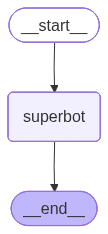

In [99]:
from IPython.display import Image, display
from langgraph.checkpoint.memory import MemorySaver

memory = MemorySaver()

def superbot(state: State):
    return {"messages": [model.invoke(state["messages"])]}




build = StateGraph(State)
build.add_node("superbot", superbot)


build.add_edge(START, "superbot")


build.add_edge("superbot", END)

printer = build.compile(checkpointer = memory)

display(Image(printer.get_graph().draw_mermaid_png()))


In [100]:
config = {"configurable" : {"thread_id": "3"}}


for m in piper.stream({"messages": "What is the recent ai news?"}, config, stream_node = "updates"):
    print(m)

Key 'additional_properties' is not supported in schema, ignoring
Key 'defs' is not supported in schema, ignoring
Key 'ref' is not supported in schema, ignoring
Key 'any_of' is not supported in schema, ignoring
Key 'example' is not supported in schema, ignoring
Key 'max_items' is not supported in schema, ignoring
Key 'max_length' is not supported in schema, ignoring
Key 'max_properties' is not supported in schema, ignoring
Key 'min_items' is not supported in schema, ignoring
Key 'min_length' is not supported in schema, ignoring
Key 'min_properties' is not supported in schema, ignoring
Key 'property_ordering' is not supported in schema, ignoring
Key 'additional_properties' is not supported in schema, ignoring
Key 'defs' is not supported in schema, ignoring
Key 'ref' is not supported in schema, ignoring
Key 'any_of' is not supported in schema, ignoring
Key 'example' is not supported in schema, ignoring
Key 'max_items' is not supported in schema, ignoring
Key 'max_length' is not supported 

ChatGoogleGenerativeAIError: Error calling model 'gemini-3.5-flash' (RESOURCE_EXHAUSTED): 429 RESOURCE_EXHAUSTED. {'error': {'code': 429, 'message': 'You exceeded your current quota, please check your plan and billing details. For more information on this error, head to: https://ai.google.dev/gemini-api/docs/rate-limits. To monitor your current usage, head to: https://ai.dev/rate-limit. \n* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_requests, limit: 5, model: gemini-3.5-flash\nPlease retry in 12.316499117s.', 'status': 'RESOURCE_EXHAUSTED', 'details': [{'@type': 'type.googleapis.com/google.rpc.Help', 'links': [{'description': 'Learn more about Gemini API quotas', 'url': 'https://ai.google.dev/gemini-api/docs/rate-limits'}]}, {'@type': 'type.googleapis.com/google.rpc.QuotaFailure', 'violations': [{'quotaMetric': 'generativelanguage.googleapis.com/generate_content_free_tier_requests', 'quotaId': 'GenerateRequestsPerMinutePerProjectPerModel-Fre

In [ ]:



for m in piper.stream({"messages": "Hi, My name is Sid and i like chess"}, config, stream_node = "values"):
    print(m)

Key 'additional_properties' is not supported in schema, ignoring
Key 'defs' is not supported in schema, ignoring
Key 'ref' is not supported in schema, ignoring
Key 'any_of' is not supported in schema, ignoring
Key 'example' is not supported in schema, ignoring
Key 'max_items' is not supported in schema, ignoring
Key 'max_length' is not supported in schema, ignoring
Key 'max_properties' is not supported in schema, ignoring
Key 'min_items' is not supported in schema, ignoring
Key 'min_length' is not supported in schema, ignoring
Key 'min_properties' is not supported in schema, ignoring
Key 'property_ordering' is not supported in schema, ignoring
Key 'additional_properties' is not supported in schema, ignoring
Key 'defs' is not supported in schema, ignoring
Key 'ref' is not supported in schema, ignoring
Key 'any_of' is not supported in schema, ignoring
Key 'example' is not supported in schema, ignoring
Key 'max_items' is not supported in schema, ignoring
Key 'max_length' is not supported 

{'tool_calling_llm': {'messages': [AIMessage(content=[{'type': 'text', 'text': "Hi Sid! It's great to meet you. \n\nChess is a fantastic game! It also happens to have a deep history with artificial intelligence—from IBM's Deep Blue defeating Garry Kasparov in 1997, to modern neural network engines like AlphaZero and Stockfish completely redefining how we understand the game today.\n\nHow do you like to enjoy chess? We can do a few things right here if you'd like:\n1. **Play a game:** We can play a text-based game of chess right here using algebraic notation (e.g., 1. e4 e5).\n2. **Talk strategy:** Discuss your favorite openings, mid-game strategies, or endgame techniques.\n3. **Puzzles:** I can set up a chess puzzle for you to solve.\n4. **Famous games:** We can analyze some famous historical games or check out recent top-grandmaster tournament news.\n\nLet me know what you're in the mood for, Sid!", 'extras': {'signature': 'EqUNCqINAQw51sdYBeoj/BmD07g1N6Vc6zClRqy/SY+69SwYUIdbqMTzkAsMg

# Human in Loop

In [ ]:
from typing_extensions import TypedDict
from typing import Annotated
from langchain_tavily import TavilySearch
from langgraph.graph.message import add_messages
from langchain_core.tools import tool
from langgraph.graph import START, END, StateGraph
from langgraph.prebuilt import ToolNode, tools_condition
from langgraph.types import Command, interrupt 
from langgraph.checkpoint.memory import MemorySaver

memory = MemorySaver()

class State(TypedDict):
    message: Annotated[list, add_messages]

graph_maker = StateGraph(State)

@tool 
def human_assistance(query: str) -> str:
    """ Requests assistance from human """
    human_response = interrupt({"query" : query})
    return human_response["data"]

search_tool = TavilySearch(max_results=2)

tools = [search_tool, human_assistance]
with_tools = model.bind_tools(tools)


def chatbot(state: State):
    print("STATE =", state)

    message = with_tools.invoke(state["messages"])
    return {"messages": [message]}

graph_maker.add_node("chatbot", chatbot)

tool_node = ToolNode(tools = tools)

graph_maker.add_node("tools", tool_node)
graph_maker.add_edge(START, "chatbot")

graph_maker.add_conditional_edges(
    "chatbot", 
    tools_condition
)





main = graph_maker.compile(checkpointer = memory)




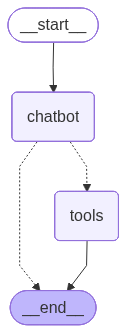

In [ ]:
from  IPython.display import Image, display

display(Image(main.get_graph().draw_mermaid_png()))

In [ ]:
from langchain_core.messages import HumanMessage, AIMessage

user_input = "I need some assistance in building AI agent. Could you request assistance for me?"
config={"configurable" : {"thread_id" :"123"}}

events = main.stream({"messages":  [
            HumanMessage(content=user_input)
        ]}, config, stream_mode ="values")


for event in events:
    if "messages" in event:
        event["messages"][-1].pretty_print()

STATE = {'message': []}


KeyError: 'messages'

In [ ]:
human_response = ("We, the experts  are here to help. We'll recommend  you check out langgraph to build your agent.")

human_command = Command(resume = {"data": human_response})

events = graph.stream(human_command, config, stream_mode = "values")

for event in events:
    if "messages" in event:
        event["messages"][-1].pretty_print()
